In [10]:
import torch
import torch.nn as nn
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [26]:
im_chan = 3  # for CelebA RGB
n_classes = 40  # Number of facial attributes for CelebA
hidden_dim = 64  # or your preferred setting

z_dim = 64
batch_size = 128
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [27]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, z_dim=10, im_chan=3, hidden_dim=64):
        super(Generator, self).__init__()
        self.z_dim = z_dim
        self.gen = nn.Sequential(
            self.make_gen_block(z_dim, hidden_dim * 8),
            self.make_gen_block(hidden_dim * 8, hidden_dim * 4),
            self.make_gen_block(hidden_dim * 4, hidden_dim * 2),
            self.make_gen_block(hidden_dim * 2, hidden_dim),
            self.make_gen_block(hidden_dim, im_chan, kernel_size=4, final_layer=True),
        )
    def make_gen_block(self, input_channels, output_channels, kernel_size=3, stride=2, final_layer=False):
        if not final_layer:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride),
                nn.BatchNorm2d(output_channels),
                nn.ReLU(inplace=True),
            )
        else:
            return nn.Sequential(
                nn.ConvTranspose2d(input_channels, output_channels, kernel_size, stride),
                nn.Tanh(),
            )
    def forward(self, noise):
        x = noise.view(len(noise), self.z_dim, 1, 1)
        return self.gen(x)

def get_noise(n_samples, z_dim, device='cpu'):
    return torch.randn(n_samples, z_dim, device=device)

class Classifier(nn.Module):
    def __init__(self, im_chan=3, n_classes=2, hidden_dim=64):
        super(Classifier, self).__init__()
        self.classifier = nn.Sequential(
            self.make_classifier_block(im_chan, hidden_dim),
            self.make_classifier_block(hidden_dim, hidden_dim * 2),
            self.make_classifier_block(hidden_dim * 2, hidden_dim * 4, stride=3),
            self.make_classifier_block(hidden_dim * 4, n_classes, final_layer=True),
        )
    def make_classifier_block(self, input_channels, output_channels, kernel_size=4, stride=2, final_layer=False):
        if not final_layer:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride),
                nn.BatchNorm2d(output_channels),
                nn.LeakyReLU(0.2, inplace=True),
            )
        else:
            return nn.Sequential(
                nn.Conv2d(input_channels, output_channels, kernel_size, stride),
            )
    def forward(self, image):
        class_pred = self.classifier(image)
        return class_pred.view(len(class_pred), -1)

In [28]:
generator = Generator(z_dim=z_dim, im_chan=im_chan, hidden_dim=hidden_dim).to(device)
gen_dict = torch.load("pretrained_celeba.pth", map_location=torch.device(device))["gen"]
generator.load_state_dict(gen_dict)
generator.eval()

Generator(
  (gen): Sequential(
    (0): Sequential(
      (0): ConvTranspose2d(64, 512, kernel_size=(3, 3), stride=(2, 2))
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): ConvTranspose2d(512, 256, kernel_size=(3, 3), stride=(2, 2))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (3): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (4): Sequential(
      (0): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2

In [29]:
classifier = Classifier(im_chan=im_chan, n_classes=n_classes, hidden_dim=hidden_dim).to(device)
class_dict = torch.load("pretrained_classifier.pth", map_location=torch.device(device))["classifier"]
classifier.load_state_dict(class_dict)
classifier.eval()

Classifier(
  (classifier): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(3, 3))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (3): Sequential(
      (0): Conv2d(256, 40, kernel_size=(4, 4), stride=(2, 2))
    )
  )
)

In [30]:
feature_names = [
    "5_o_Clock_Shadow", "Arched_Eyebrows", "Attractive", "Bags_Under_Eyes", "Bald",
    "Bangs", "Big_Lips", "Big_Nose", "Black_Hair", "Blond_Hair", "Blurry",
    "Brown_Hair", "Bushy_Eyebrows", "Chubby", "Double_Chin", "Eyeglasses",
    "Goatee", "Gray_Hair", "Heavy_Makeup", "High_Cheekbones", "Male",
    "Mouth_Slightly_Open", "Mustache", "Narrow_Eyes", "No_Beard", "Oval_Face",
    "Pale_Skin", "Pointy_Nose", "Receding_Hairline", "Rosy_Cheeks", "Sideburns",
    "Smiling", "Straight_Hair", "Wavy_Hair", "Wearing_Earrings", "Wearing_Hat",
    "Wearing_Lipstick", "Wearing_Necklace", "Wearing_Necktie", "Young"
]

target_attr = "Male"
target_idx = feature_names.index(target_attr)

In [31]:
def get_noise(batch_size, z_dim, device):
    return torch.randn(batch_size, z_dim, 1, 1, device=device)

def show_tensor_images(image_tensor, num_images=16, size=(3, 64, 64), nrow=4):
    image_tensor = (image_tensor[:num_images] + 1) / 2
    grid = make_grid(image_tensor.detach().cpu(), nrow=nrow)
    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.imshow(np.transpose(grid, (1,2,0)))
    plt.show()


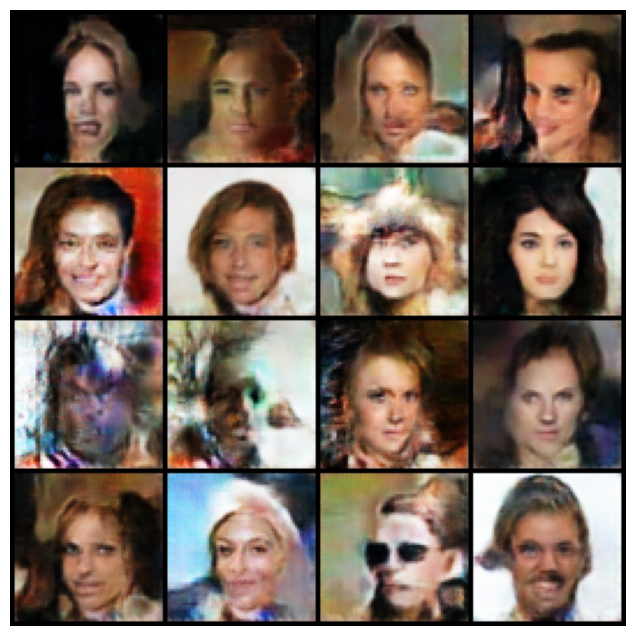

In [32]:
noise = get_noise(batch_size, z_dim, device=device)
fake_images = generator(noise)
show_tensor_images(fake_images, num_images=16, size=image_size, nrow=4)


In [33]:
noise = get_noise(batch_size, z_dim, device=device)
noise = noise.clone().requires_grad_(True)
optimizer = torch.optim.SGD([noise], lr=0.5)

classification_history = []
image_history = []

for step in range(grad_steps):
    optimizer.zero_grad()
    generated = generator(noise)
    pred = classifier(generated)
    classification_history.append(pred.detach().cpu().numpy())
    image_history.append(generated.detach().cpu())

    # Maximize 'Male'
    loss = -pred[:, target_idx].sum()
    loss.backward()
    optimizer.step()

classification_history = np.stack(classification_history)  # (steps, batch, features)


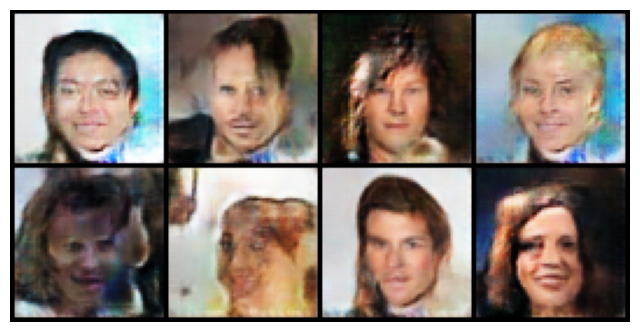

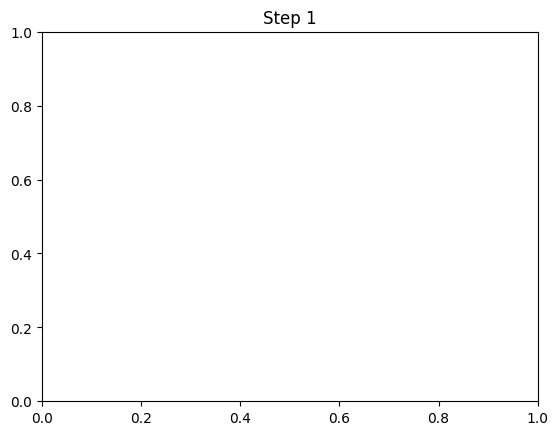

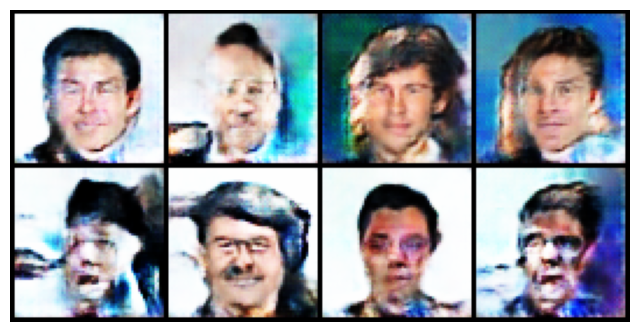

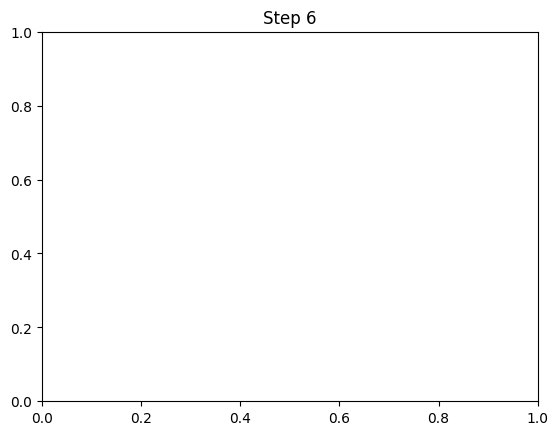

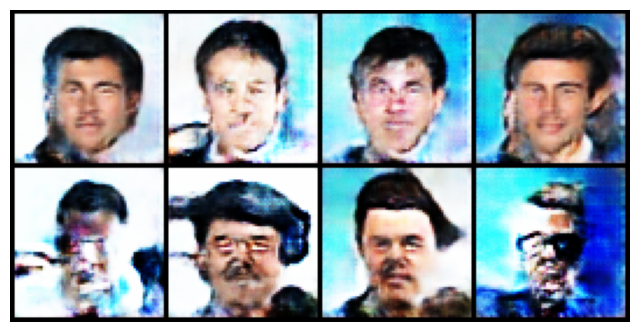

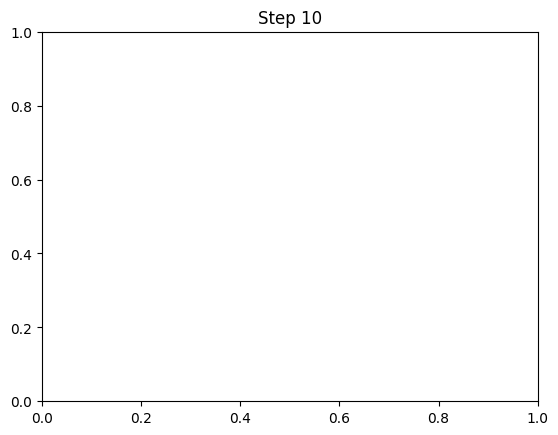

In [34]:
for i in [0, grad_steps//2, grad_steps-1]:
    show_tensor_images(image_history[i], num_images=8, size=image_size, nrow=4)
    plt.title(f"Step {i+1}")


In [35]:
# Show classifier predictions for first few images at last step
last_preds = classification_history[-1][:8]
df = pd.DataFrame(last_preds, columns=feature_names)
print(df[[target_attr] + ["Smiling","Bald","Young","Heavy_Makeup","Goatee"]])


        Male   Smiling       Bald     Young  Heavy_Makeup    Goatee
0  16.334082 -2.761612  -7.492734  1.230799     -9.750159 -1.115255
1   8.496799 -1.731810  -6.995019  0.712864     -7.508636 -4.460291
2  13.477686 -0.871702  -5.752275  0.447713     -9.355919 -3.329630
3  15.606863  0.472926  -9.410008  1.914738     -9.707433 -3.724631
4  11.682279 -6.133995  -7.316329  1.303457     -9.855770 -0.878919
5  22.483541  0.949686  -8.634639 -3.214689    -18.099941 -2.758927
6  18.435890 -3.603673 -10.697610 -1.168313    -14.747944 -2.063273
7  13.970576 -8.860624 -10.203057  0.255809    -12.509209 -1.383790


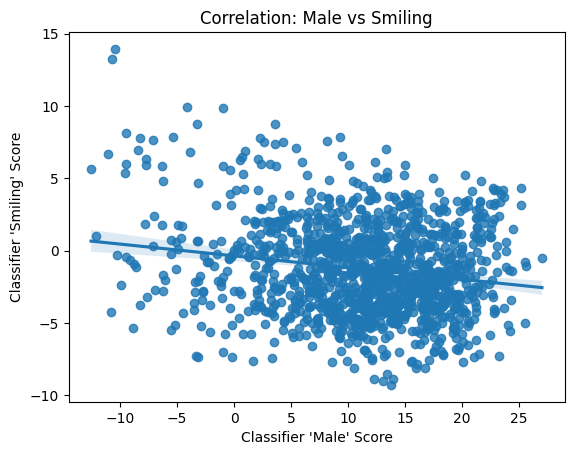

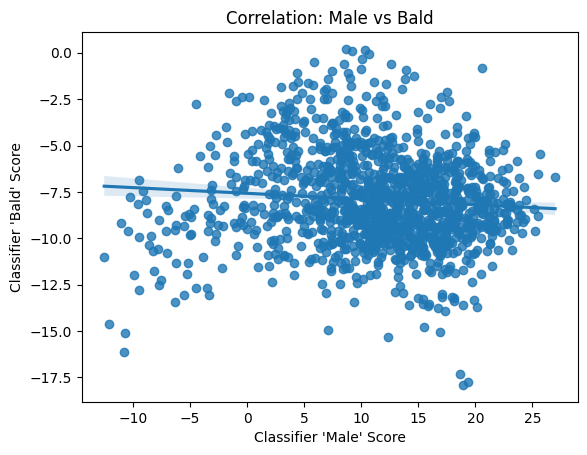

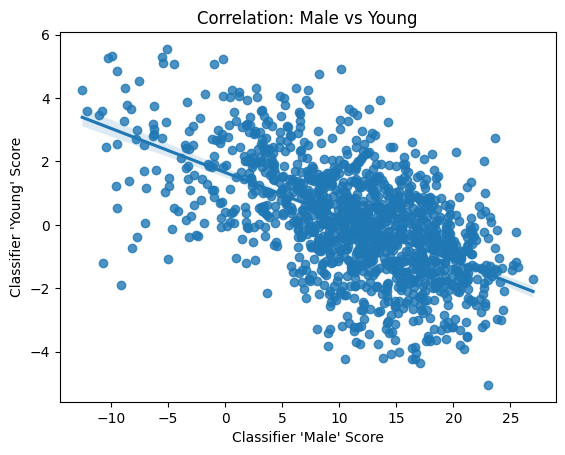

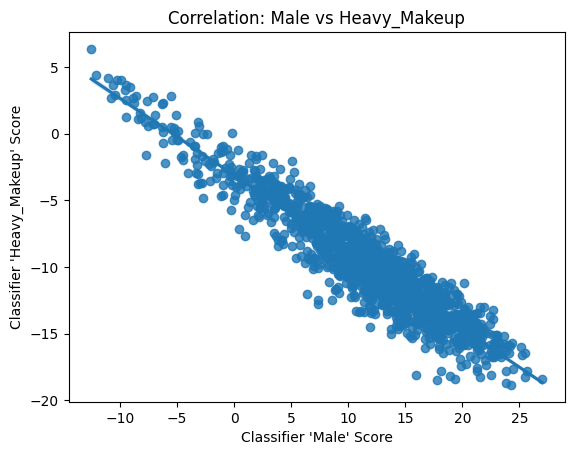

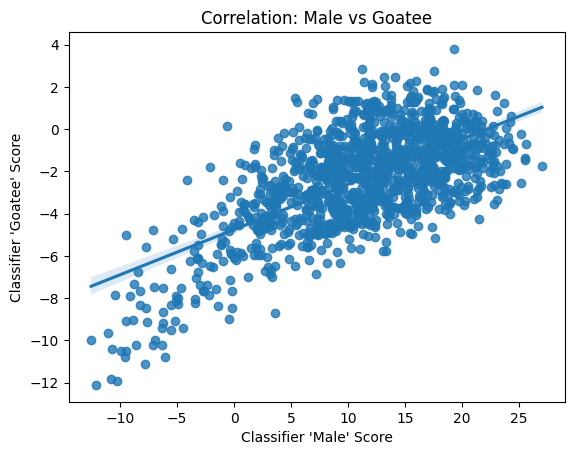

In [36]:
male_scores = classification_history[..., target_idx].reshape(-1)
for feat in ["Smiling", "Bald", "Young", "Heavy_Makeup", "Goatee"]:
    idx = feature_names.index(feat)
    sns.regplot(
        x=male_scores,
        y=classification_history[..., idx].reshape(-1),
        fit_reg=True
    )
    plt.xlabel("Classifier 'Male' Score")
    plt.ylabel(f"Classifier '{feat}' Score")
    plt.title(f"Correlation: Male vs {feat}")
    plt.show()


In [37]:
cov_matrix = np.cov(classification_history.reshape(-1, len(feature_names)).T)
male_covs = cov_matrix[target_idx]
top_indices = np.argsort(-np.abs(male_covs))
print("Feature      Covariance")
for idx in top_indices[1:11]:  # Skip 'male' self-covariance
    print(f"{feature_names[idx]:<12} {male_covs[idx]:.3f}")


Feature      Covariance
Wearing_Lipstick -32.855
Heavy_Makeup -29.019
Blond_Hair   -23.137
No_Beard     -20.215
Bangs        -17.419
Wearing_Earrings -15.939
Wearing_Necklace -14.876
Sideburns    13.579
Mustache     12.801
Brown_Hair   -11.588


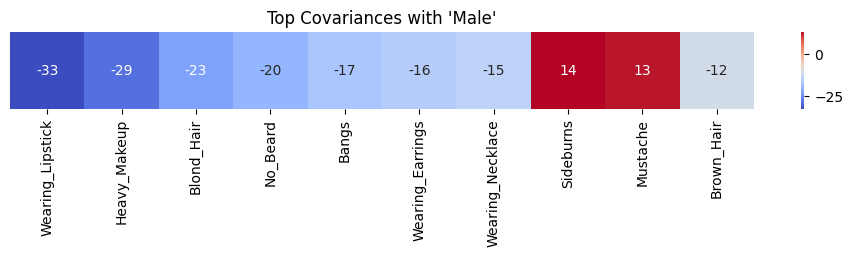

In [38]:
topN = 10
indices = top_indices[1:topN+1]
cov_vals = male_covs[indices]

plt.figure(figsize=(12,1))
sns.heatmap([cov_vals], annot=True,
            xticklabels=[feature_names[i] for i in indices],
            cmap='coolwarm', cbar=True)
plt.yticks([])
plt.title("Top Covariances with 'Male'")
plt.show()
